Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
content_df = pd.read_csv("../data/raw/content_based_data.csv")
content_df.head()

,Artist,Track,Album,Genre,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity
0,Gorillaz,Feel Good Inc.,Demon Days,Alt,0.818,0.705,-6.679,0.1770,0.008360,0.002330,0.6130,0.772,138.559,0.983053
1,Gorillaz,Rhinestone Eyes,Plastic Beach,Alt,0.676,0.703,-5.815,0.0302,0.086900,0.000687,0.0463,0.852,92.761,0.888511
2,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),Alt,0.695,0.923,-3.930,0.0522,0.042500,0.046900,0.1160,0.551,108.014,0.573784
3,Gorillaz,On Melancholy Hill,Plastic Beach,Alt,0.689,0.739,-5.810,0.0260,0.000015,0.509000,0.0640,0.578,120.423,0.925464
4,Gorillaz,Clint Eastwood,Gorillaz,Alt,0.663,0.694,-8.627,0.1710,0.025300,0.000000,0.0698,0.525,167.953,0.955958


Feature Engineering

In [3]:
# Create new features

content_df["mood_score"] = (content_df["Valence"] + content_df["Energy"]) / 2

content_df["intensity"] = content_df["Energy"] * content_df["Loudness"]

# Verify
content_df.head()

,Artist,Track,Album,Genre,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,mood_score,intensity
0,Gorillaz,Feel Good Inc.,Demon Days,Alt,0.818,0.705,-6.679,0.1770,0.008360,0.002330,0.6130,0.772,138.559,0.983053,0.7385,-4.708695
1,Gorillaz,Rhinestone Eyes,Plastic Beach,Alt,0.676,0.703,-5.815,0.0302,0.086900,0.000687,0.0463,0.852,92.761,0.888511,0.7775,-4.087945
2,Gorillaz,New Gold (feat. Tame Impala and Bootie Brown),New Gold (feat. Tame Impala and Bootie Brown),Alt,0.695,0.923,-3.930,0.0522,0.042500,0.046900,0.1160,0.551,108.014,0.573784,0.7370,-3.627390
3,Gorillaz,On Melancholy Hill,Plastic Beach,Alt,0.689,0.739,-5.810,0.0260,0.000015,0.509000,0.0640,0.578,120.423,0.925464,0.6585,-4.293590
4,Gorillaz,Clint Eastwood,Gorillaz,Alt,0.663,0.694,-8.627,0.1710,0.025300,0.000000,0.0698,0.525,167.953,0.955958,0.6095,-5.987138


In [4]:
content_df[["mood_score","intensity"]].describe()

,mood_score,intensity
count,20594.000000,20594.000000
mean,0.582627,-4.137293
std,0.191752,1.600559
min,0.000000,-25.603000
25%,0.461500,-4.872115
50%,0.606000,-3.980082
75%,0.726500,-3.213220
max,0.981000,0.907120


Correlation Matrix

In [5]:
# Select numeric columns
numeric_df = content_df.select_dtypes(include=["float64", "int64"])

corr_matrix = numeric_df.corr()

corr_matrix

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,mood_score,intensity
Danceability,1.000000,0.237554,0.354298,0.210059,-0.279212,-0.319717,-0.084534,0.465989,-0.062556,0.067164,0.431083,-0.032437
Energy,0.237554,1.000000,0.744161,0.065557,-0.656924,-0.310084,0.173544,0.388401,0.158545,0.063789,0.807407,-0.272285
Loudness,0.354298,0.744161,1.000000,0.034498,-0.547698,-0.545410,0.086716,0.311189,0.143624,0.169795,0.615026,0.126100
Speechiness,0.210059,0.065557,0.034498,1.000000,-0.077373,-0.110622,0.085404,0.058925,0.038530,-0.072991,0.074356,-0.082745
Acousticness,-0.279212,-0.656924,-0.547698,-0.077373,1.000000,0.274340,-0.040251,-0.198494,-0.129348,-0.118750,-0.494130,0.188795
Instrumentalness,-0.319717,-0.310084,-0.545410,-0.110622,0.274340,1.000000,-0.060132,-0.270560,-0.076246,-0.139358,-0.346482,0.027617
Liveness,-0.084534,0.173544,0.086716,0.085404,-0.040251,-0.060132,1.000000,0.031254,0.007730,-0.048333,0.116975,-0.113197
Valence,0.465989,0.388401,0.311189,0.058925,-0.198494,-0.270560,0.031254,1.000000,0.091974,-0.003725,0.857272,-0.153748
Tempo,-0.062556,0.158545,0.143624,0.038530,-0.129348,-0.076246,0.007730,0.091974,1.000000,0.027552,0.147471,-0.024960
Popularity,0.067164,0.063789,0.169795,-0.072991,-0.118750,-0.139358,-0.048333,-0.003725,0.027552,1.000000,0.033256,0.100178


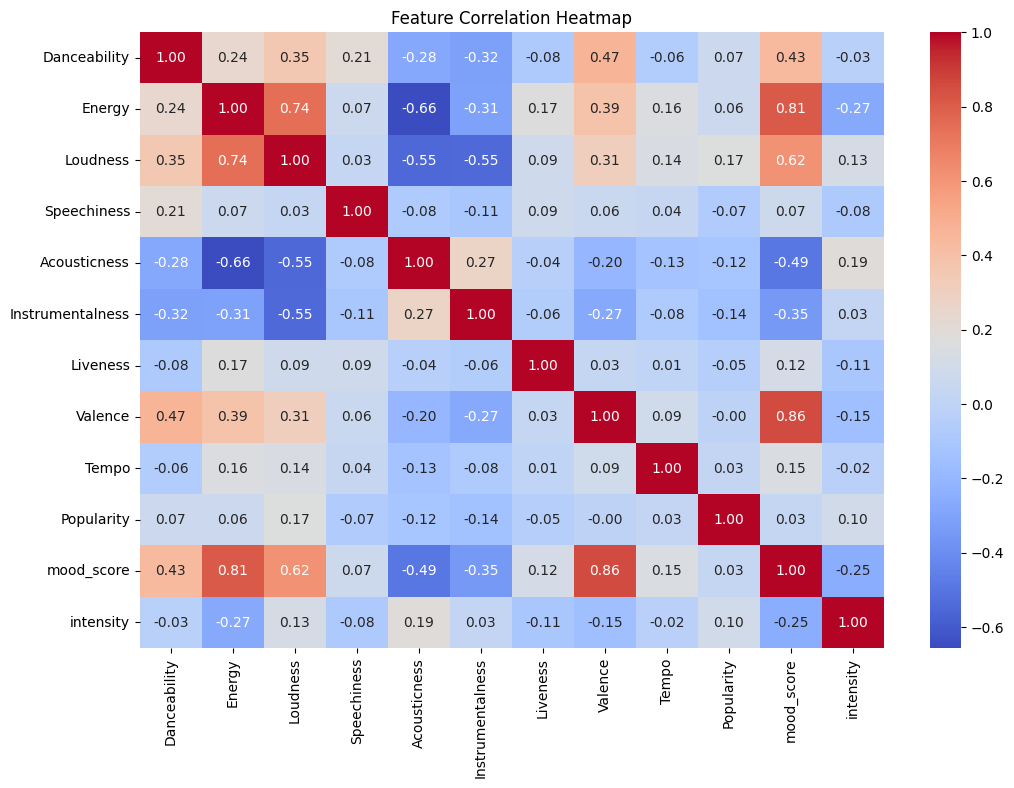

In [6]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
# Create folder if not exists
os.makedirs("../data/processed", exist_ok=True)

# Save dataset
content_df.to_csv("../data/processed/content_featured_data.csv", index=False)

print("Featured dataset saved")

Featured dataset saved
